In [8]:
import jax
import jax.numpy as jnp
import dcegm

jax.config.update("jax_enable_x64", True)

## Model


This notebook develops a minimal five-period model with **two continuous deterministic experience stocks** — one per occupation — alongside stochastic wealth. 

The model extends the single-experience minimal example by adding a second occupation track. The agent chooses among three discrete alternatives in each working period. We compare an implementation with discrete versus continuous experience stocks.

| Choice | Label | Interpretation |
|:---:|:---:|:---|
| 0 | Occupation 0 | Red Occupation; income proportional to red experience $x_0$ |
| 1 | Occupation 1 | Green Occupation; income proportional to green experience $x_1$ |
| 2 | No work | Leisure / unemployment / retirement ; no income, no experience gained |

Last period is mandatory retirement (forced choice 2), with pension income depending on accumulated experience. 

## Model Setup

In [1]:
params = {}
params["interest_rate"] = 0.02
params["max_wealth"] = 50
params["wage_constant"] = 3
params["wage_exp_green"] = 0.5
params["wage_exp_red"] = 0.8
params["income_shock_std"] = 1
params["income_shock_mean"] = 0
params["taste_shock_scale"] = 1
params["discount_factor"] = 0.95
params["rho"] = 0.9
params["delta"] = 1.5
params["beta_green"] = 0.2
params["beta_red"] = 0.1
params

{'interest_rate': 0.02,
 'max_wealth': 50,
 'wage_constant': 3,
 'wage_exp_green': 0.5,
 'wage_exp_red': 0.8,
 'income_shock_std': 1,
 'income_shock_mean': 0,
 'taste_shock_scale': 1,
 'discount_factor': 0.95,
 'rho': 0.9,
 'delta': 1.5,
 'beta_green': 0.2,
 'beta_red': 0.1}

In [9]:
# Utility functions
def flow_util(consumption, choice, params):
    rho = params["rho"]
    beta_green = params["beta_green"]
    beta_red = params["beta_red"]
    disutility = beta_red * (choice == 0) + beta_green * (choice == 1)
    u = consumption ** (1 - rho) / (1 - rho) - disutility
    return u


def marginal_utility(consumption, params):
    rho = params["rho"]
    u_prime = consumption ** (-rho)
    return u_prime


def inverse_marginal_utility(marginal_utility, params):
    rho = params["rho"]
    return marginal_utility ** (-1 / rho)


utility_functions = {
    "utility": flow_util,
    "inverse_marginal_utility": inverse_marginal_utility,
    "marginal_utility": marginal_utility,
}

In [10]:
def state_specific_choice_set(
    period,
    lagged_choice,
    model_specs,
):
    # Once the agent choses retirement, she can only choose retirement thereafter.
    # Hence, retirement is an absorbing state.
    if lagged_choice == 2:
        choice_set = [2]
    elif period == 4:
        choice_set = [2]
    else:
        choice_set = model_specs["choices"]

    return choice_set

In [11]:
def final_period_utility(wealth: float, choice: int, params):
    return flow_util(wealth, choice, params)


def marginal_final(wealth, choice):
    return marginal_utility(wealth, params)


utility_functions_final_period = {
    "utility": final_period_utility,
    "marginal_utility": marginal_final,
}

In [12]:
model_specs = {
    "choices": [0, 1, 2],
}

## Discrete Experience Stocks

In [13]:
model_config = {
    "n_periods": 5,
    "choices": [0, 1, 2],
    "continuous_states": {
        "assets_end_of_period": jnp.linspace(0, 50, 100),
    },
    "deterministic_states": {
        "exp_green": jnp.arange(0, 7, dtype=int),
        "exp_red": jnp.arange(0, 7, dtype=int),
    },
    "n_quad_points": 5,
}

In [14]:
def next_period_deterministic_state(
    period,
    choice,
    lagged_choice,
    exp_green,
    exp_red,
):
    next_exp_green = exp_green + (choice == 1)
    next_exp_red = exp_red + (choice == 0)
    return {
        "period": period + 1,
        "exp_green": next_exp_green,
        "exp_red": next_exp_red,
        "lagged_choice": choice,
    }

In [15]:
def sparsity_condition(
    period,
    lagged_choice,
    exp_green,
    exp_red,
):
    if (exp_green + exp_red) > period:
        return False
    elif (exp_green > 0) & (lagged_choice == 0) & (period == 1):
        return False
    elif (exp_red > 0) & (lagged_choice == 1) & (period == 1):
        return False
    elif ((exp_red + exp_green) == 0) & (lagged_choice != 2):
        return False
    else:
        return True

In [16]:
state_space_functions_discrete_exp = {
    "state_specific_choice_set": state_specific_choice_set,
    "next_period_deterministic_state": next_period_deterministic_state,
    "sparsity_condition": sparsity_condition,
}

In [17]:
def budget_constraint_discrete_exp(
    lagged_choice,
    exp_green,
    exp_red,
    asset_end_of_previous_period,
    income_shock_previous_period,
    params,
):
    interest_factor = 1 + params["interest_rate"]
    wage = (
        params["wage_constant"]
        + params["wage_exp_green"] * exp_green * (lagged_choice == 1)
        + params["wage_exp_red"] * exp_red * (lagged_choice == 0)
    )
    resource = (
        interest_factor * asset_end_of_previous_period
        + (wage + income_shock_previous_period) * (lagged_choice != 2)
        + (wage + income_shock_previous_period) * 0.5 * (lagged_choice == 2)
    )
    return jnp.maximum(resource, 0.5)

In [18]:
model = dcegm.setup_model(
    model_config=model_config,
    model_specs=model_specs,
    utility_functions=utility_functions,
    utility_functions_final_period=utility_functions_final_period,
    state_space_functions=state_space_functions_discrete_exp,
    stochastic_states_transitions={},
    budget_constraint=budget_constraint_discrete_exp,
)

Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  36
The batch size of the backwards induction is  35
The batch size of the backwards induction is  34
The batch size of the backwards induction is  33
The batch size of the backwards induction is  32
The batch size of the backwards induction is  31
The batch size of the backwards induction is  30
The batch size of the backwards induction is  29
The batch size of the backwards induction is  28
The batch size of the backwards induction is  27
The batch size of the backwards induction is  26
The batch size of the backwards induction is  25
The batch size of the backwards induction is  24
The batch size of the backwards induction is  23
The batch size of the backwards induction is  22
The batch size of the backwards induction is  21
The batch 

/Users/annicagehlen/Documents/projects/di-occupations-model/strenuous-jobs/submodules/dcegm/src/dcegm/pre_processing/model_structure/state_choice_space.py:295: UserWarning: 



 Some states are not child states of any state-choice combination or stochastic transition. Please revisit the sparsity condition. 
 
An example of a state that is not a child state is: 
 
{'period': np.uint8(1), 'lagged_choice': np.uint8(0), 'exp_green': np.uint8(0), 'exp_red': np.uint8(1), 'dummy_stochastic': np.uint8(0)} 
 

  warnings.warn(


In [19]:
solved_model = model.solve(params)
policy_function = solved_model.policy

In [20]:
# pd.DataFrame(policy_function)

In [21]:
n_agents = 100
states_initial = {
    "n_agents": n_agents,
    "assets_begin_of_period": jnp.zeros(n_agents),
    "exp_green": jnp.zeros(n_agents),
    "exp_red": jnp.zeros(n_agents),
    "lagged_choice": jnp.zeros(n_agents),
    "period": jnp.zeros(n_agents, dtype=int),
}

In [22]:
simulate = model.get_solve_and_simulate_func(states_initial=states_initial, seed=99)

In [23]:
df = simulate(params)

<Axes: title={'center': 'Choice Probabilities'}, xlabel='period'>

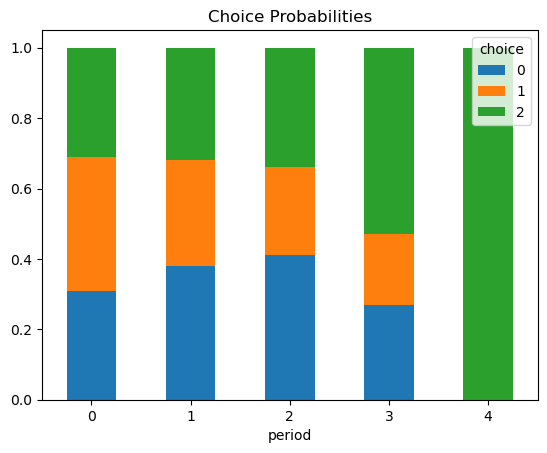

In [24]:
df.groupby("period").choice.value_counts(normalize=True).unstack().plot(
    stacked=True, kind="bar", rot=0, title="Choice Probabilities"
)

<Axes: title={'center': 'Experience in Green Occupation'}, xlabel='period'>

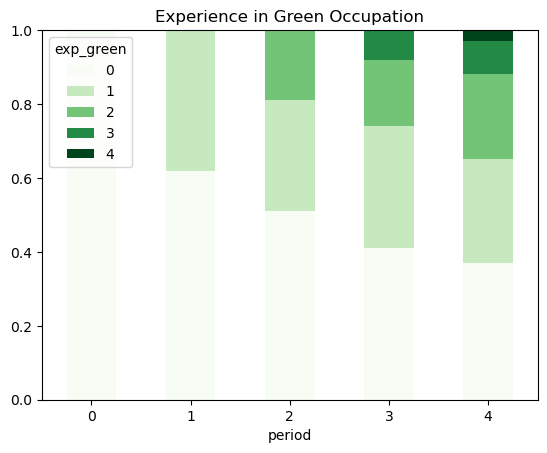

In [25]:
df.groupby("period").exp_green.value_counts(normalize=True).unstack().plot(
    stacked=True,
    kind="bar",
    rot=0,
    cmap="Greens",
    title="Experience in Green Occupation",
)

<Axes: title={'center': 'Experience in Red Occupation'}, xlabel='period'>

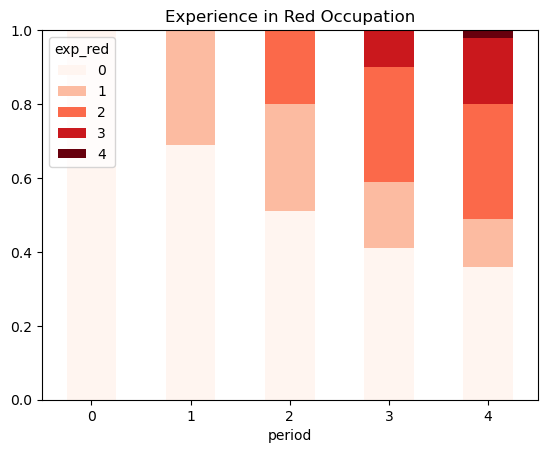

In [26]:
df.groupby("period").exp_red.value_counts(normalize=True).unstack().plot(
    stacked=True, kind="bar", rot=0, cmap="Reds", title="Experience in Red Occupation"
)

<Axes: title={'center': 'Average Consumption'}, xlabel='period'>

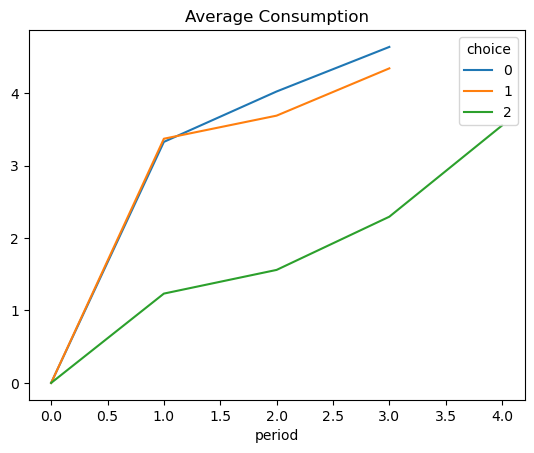

In [27]:
df.groupby(["period", "choice"]).consumption.mean().unstack().plot(
    rot=0, title="Average Consumption"
)

## Continuous Experience Stocks

In [28]:
model_config = {
    "n_periods": 5,
    "choices": [0, 1, 2],
    "continuous_states": {
        "assets_end_of_period": jnp.linspace(0, 50, 100),
        "assets_begin_of_period": jnp.linspace(0, 50, 100),
        "exp_green": jnp.arange(0, 1, 5, dtype=float),
        "exp_red": jnp.arange(0, 1, 5, dtype=float),
    },
    "n_quad_points": 5,
    "upper_envelope": {"method": "druedahl_jorgensen"},
}

In [29]:
def next_period_deterministic_state_cont(
    period,
    choice,
    lagged_choice,
):
    return {
        "period": period + 1,
        "lagged_choice": choice,
    }

In [30]:
def next_period_continuous_state(
    choice,
    period,
    exp_green,
    exp_red,
):

    exp_red_years = period * exp_red
    exp_green_years = period * exp_green
    add_red = choice == 0
    add_green = choice == 1

    period_scale = period.clip(min=1)
    exp_red_lag_years = exp_red_years * (period_scale - 1).clip(min=0)
    exp_red_next = (exp_red_lag_years + add_red) / period_scale

    exp_green_lag_years = exp_green_years * (period_scale - 1).clip(min=0)
    exp_green_next = (exp_green_lag_years + add_green) / period_scale

    return {
        "exp_red": exp_red_next,
        "exp_green": exp_green_next,
    }

In [31]:
state_space_functions_cont_exp = {
    "state_specific_choice_set": state_specific_choice_set,
    "next_period_deterministic_state": next_period_deterministic_state_cont,
    "next_period_continuous_state": next_period_continuous_state,
}

In [32]:
def budget_constraint_cont_exp(
    period,
    lagged_choice,
    exp_green,
    exp_red,
    asset_end_of_previous_period,
    income_shock_previous_period,
    params,
):
    exp_green_years = exp_green * period
    exp_red_years = exp_red * period
    interest_factor = 1 + params["interest_rate"]
    wage = (
        params["wage_constant"]
        + params["wage_exp_green"] * exp_green_years * (lagged_choice == 1)
        + params["wage_exp_red"] * exp_red_years * (lagged_choice == 0)
    )
    resource = (
        interest_factor * asset_end_of_previous_period
        + (wage + income_shock_previous_period) * (lagged_choice != 2)
        + (wage + income_shock_previous_period) * 0.5 * (lagged_choice == 2)
    )
    return jnp.maximum(resource, 0.5)

In [33]:
# model = dcegm.setup_model(
#     model_config=model_config,
#     model_specs=model_specs,
#     utility_functions=utility_functions,
#     utility_functions_final_period=utility_functions_final_period,
#     state_space_functions=state_space_functions_cont_exp,
#     stochastic_states_transitions={},
#     budget_constraint=budget_constraint_cont_exp,
# )

In [34]:
# solved_model = model.solve(params)
# policy_function = solved_model.policy

In [ ]:
# n_agents=100
# states_initial = {
#     "n_agents": n_agents,
#     "assets_begin_of_period": jnp.zeros(n_agents),
#     "exp_green": jnp.zeros(n_agents),
#     "exp_red": jnp.zeros(n_agents),
#     "lagged_choice": jnp.zeros(n_agents),
#     "period": jnp.zeros(n_agents, dtype=int)
# }

In [35]:
# simulate=model.get_solve_and_simulate_func(states_initial=states_initial, seed=99)

In [ ]:
# df.groupby("period").choice.value_counts(normalize=True).unstack().plot(stacked=True, kind="bar", rot=0, title="Choice Probabilities")

In [ ]:
# df.groupby("period").exp_green.value_counts(normalize=True).unstack().plot(stacked=True, kind="bar", rot=0, cmap="Greens", title="Experience in Green Occupation")

In [ ]:
# df.groupby("period").exp_red.value_counts(normalize=True).unstack().plot(stacked=True, kind="bar", rot=0, cmap="Reds", title="Experience in Red Occupation")

In [ ]:
# df.groupby(["period","choice"]).consumption.mean().unstack().plot(rot=0, title="Average Consumption")